In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
"""End-to-end mock demo for recon_jax.

1. Draw a known Gaussian linear field and evolve it with the JaxPM forward model.
2. Sample a mock galaxy catalogue from the evolved field and add photo-z scatter
   to the line-of-sight coordinate.
3. Reconstruct the density field from the *scattered* catalogue alone.
4. Report the correlation between the reconstruction and the truth, and save a
   diagnostic figure.

Run:  python examples/demo.py
"""
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

from recon_jax import GalaxyCatalog, ReconConfig, Reconstructor, make_mock_catalog
from recon_jax.painting import galaxy_bias


def corr(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    return float(np.corrcoef(a, b)[0, 1])



cfg = ReconConfig(
    nc=32,
    box_size=140.0,
    n_body=True,            # 2LPT forward model (fast); set True for full PM
    b1=1.0,
    b2=0.0,
    galaxy_fac=1.0,
        prior_fac=0.3,           # lighter prior -> less small-scale shrinkage
    redshift_fac=1.0,
    anneal_scales=(2,1,0),
    maxiter=(25, 25, 25),
    seed=0,
    z_init=19.0,
    z_final=7.0,
)

rec = Reconstructor(cfg)
rng = np.random.default_rng(42)

truth_linear: shape=(32, 32, 32)
truth_delta:  shape=(32, 32, 32), mean=-0.0000, std=0.2453
truth_g:      shape=(32, 32, 32), mean=-0.0000, std=0.2453


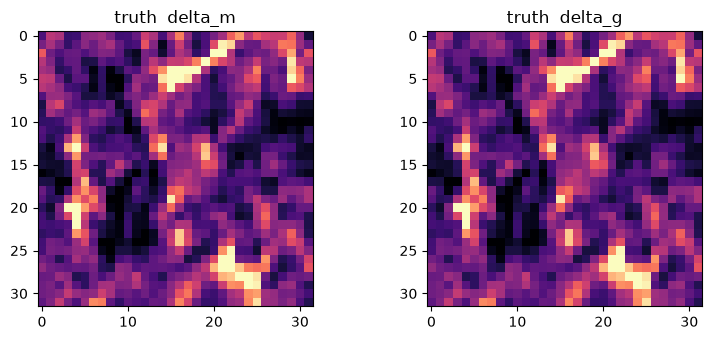

In [30]:
# --- ground-truth field only ------------------------------------------
truth_linear = rec.forward.sample_linear_field(cfg.seed)
truth_delta = np.asarray(rec.forward.matter_overdensity(truth_linear))
truth_g = np.asarray(galaxy_bias(truth_delta, cfg.b1, cfg.b2))

print(f"truth_linear: shape={truth_linear.shape}")
print(f"truth_delta:  shape={truth_delta.shape}, "
      f"mean={truth_delta.mean():.4f}, std={truth_delta.std():.4f}")
print(f"truth_g:      shape={truth_g.shape}, "
      f"mean={truth_g.mean():.4f}, std={truth_g.std():.4f}")

# quick sanity-check slice
sl = cfg.nc // 2
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
vmin, vmax = np.percentile(truth_delta[sl], [2, 98])
ax[0].imshow(truth_delta[sl], vmin=vmin, vmax=vmax, cmap="magma")
ax[0].set_title("truth  delta_m")
ax[1].imshow(truth_g[sl], vmin=vmin, vmax=vmax, cmap="magma")
ax[1].set_title("truth  delta_g")

fig.tight_layout()

In [33]:
# --- mock catalogue (uses truth_g from previous cell) -----------------
n_gal = 20000
los_sigma = 0.1  # grid cells of redshift error (photo-z-like)
catalog, true_pos = make_mock_catalog(truth_g, n_gal, los_sigma, rng, cfg.nc)
print(f"mock: {catalog.num_gal} galaxies, los_sigma = {los_sigma} cells")

# --- 3. reconstruction ----------------------------------------------
out = rec.run(catalog, seed=1)

# --- 4. diagnostics -------------------------------------------------
c = corr(out["delta_m"], truth_delta)
print(f"\nreconstructed delta_m vs truth: correlation = {c:.3f}")

mock: 20000 galaxies, los_sigma = 0.1 cells
[stage 0] R=   2 cells  loss 2.9933e+04 -> 2.9826e+04  (10.4s)
[stage 1] R=   1 cells  loss 2.9759e+04 -> 2.9710e+04  (21.6s)
[stage 2] R=   0 cells  loss 2.9512e+04 -> 2.9210e+04  (31.7s)

reconstructed delta_m vs truth: correlation = 0.442


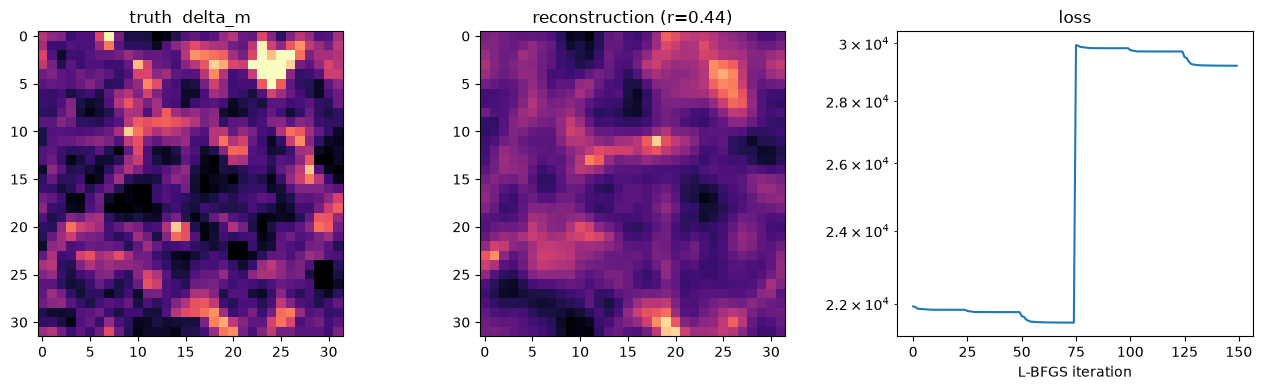

In [35]:
sl = 10
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
vmin, vmax = np.percentile(truth_delta[sl], [2, 98])
ax[0].imshow(truth_delta[:,:,sl], vmin=vmin, vmax=vmax, cmap="magma")
ax[0].set_title("truth  delta_m")
ax[1].imshow(out["delta_m"][:,:,sl], vmin=vmin, vmax=vmax, cmap="magma")
ax[1].set_title(f"reconstruction (r={c:.2f})")
ax[2].plot(out["loss_history"])
ax[2].set_yscale("log")
ax[2].set_title("loss")
ax[2].set_xlabel("L-BFGS iteration")

fig.tight_layout()
# outpng = os.path.join(os.path.dirname(__file__), "demo_result.png")
# fig.savefig(outpng, dpi=110)

In [3]:
def downsample_grid(grid: np.ndarray, factor):
    """Block-average downsample by `factor` along each axis (512³ → 256³)."""
    G = grid.shape[0]
    if G % factor != 0:
        raise ValueError(f"Grid size {G} not divisible by downsample factor {factor}")
    g = G // factor
    f = factor
    return grid.reshape(g, f, g, f, g, f).mean(axis=(1, 3, 5)).astype(np.float32)

In [117]:
D = np.load('../../simulation/Fiducial_z_7.14/Dbox_grid_017_512.npy')
D = 10**D
D = downsample_grid(D, 4)
pos = np.load('../../simulation/Fiducial_z_7.14/Halo_Position.npy')
Muv = np.load('../../simulation/Fiducial_z_7.14/Muv.npy')
idx = Muv < -17
Muv = Muv[idx]
pos = pos[idx]

In [118]:
# --- simulation truth field + galaxy catalog ---------------------------
# Sherwood box: 160 cMpc/h, pos[:,0]=LOS, pos[:,1:]=transverse.
# recon_jax expects positions[:,2]=LOS and field axes (trans1, trans2, los).
from astropy.stats import sigma_clip
SIM_BOX = 160.0   # cMpc/h
SIM_Z = 7.14
nc_sim = D.shape[0]

# matter overdensity from Dbox (physical density -> delta, then axis reorder)
truth_delta = D.astype(np.float32)
truth_delta = np.where(truth_delta>100,100,truth_delta)
truth_delta = truth_delta / np.nanmean(sigma_clip(truth_delta,sigma=3,maxiters=10)) - 1.0
truth_delta = np.transpose(truth_delta, (1, 2, 0))  # (los,*,*) -> (*,*,los)

# spec-z catalog: map (LOS, trans1, trans2) -> (trans1, trans2, LOS)
xyz_grid = np.stack([
    pos[:, 1] * nc_sim / SIM_BOX,
    pos[:, 2] * nc_sim / SIM_BOX,
    pos[:, 0] * nc_sim / SIM_BOX,
], axis=1).astype(np.float32)

xyz_grid = np.mod(xyz_grid, nc_sim)
# mod 操作：
# pos=159.99 -> 63.996，OK
# pos=160.0  -> 64.0，超出网格；mod 后 -> 0.0（周期 wrap）

los_sigma = np.full(len(xyz_grid), 0.1, dtype=np.float32)  # spec-z: small error in cells
catalog = GalaxyCatalog.from_arrays(xyz_grid, los_sigma)

# align recon config with the simulation box / redshift
cfg_sim = ReconConfig(
    nc=nc_sim,
    box_size=SIM_BOX,
    z_init=20.0,
    z_final=SIM_Z,
    n_body=True,
    b1=1.0,
    b2=0.1,
    galaxy_fac=1.0,
    prior_fac=0.3,
    redshift_fac=1.0,
    anneal_scales=(2.0, 1.0,0),
    maxiter=(20, 10, 10),
    fit_los=False,
    seed=0,
    los_axis=2,
)
rec_sim = Reconstructor(cfg_sim,likelihood="poisson")

print(f"catalog: {catalog.num_gal} galaxies on {nc_sim}^3 grid, number density = {catalog.num_gal/SIM_BOX**3:.3f} per Mpc^3")
print(f"truth_delta: mean={truth_delta.mean():.4f}, std={truth_delta.std():.4f}")
print(f"cfg_sim: box={SIM_BOX} cMpc/h, z={SIM_Z}, a_final={cfg_sim.a_final:.4f}")

/opt/miniconda3/envs/jax/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


catalog: 98417 galaxies on 128^3 grid, number density = 0.024 per Mpc^3
truth_delta: mean=0.1953, std=1.8065
cfg_sim: box=160.0 cMpc/h, z=7.14, a_final=0.1229


In [71]:
# --- reconstruction from simulation catalog ---------------------------
out_sim = rec_sim.run(catalog, seed=1)

[stage 0] R= 2.0 cells  loss 5.6978e+04 -> 5.4339e+04  (213.4s)
[stage 1] R= 1.0 cells  loss 5.3737e+04 -> 5.3484e+04  (320.7s)
[stage 2] R=   0 cells  loss 5.2542e+04 -> 5.1743e+04  (442.4s)


In [53]:
c_sim = corr(out_sim["delta_m"], truth_delta)
print(f"reconstructed delta_m vs Sherwood truth: r = {c_sim:.3f}")

reconstructed delta_m vs Sherwood truth: r = 0.089


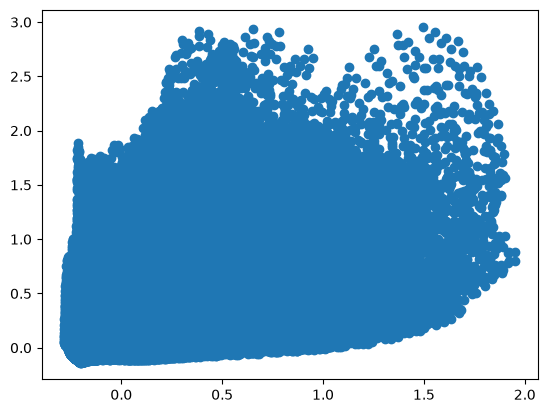

In [143]:
from scipy.ndimage import gaussian_filter
plt.scatter(gaussian_filter(out_sim["delta_m"],3).flatten(),gaussian_filter(truth_delta,3).flatten())

In [87]:
pos_cat.shape


(30810, 3)

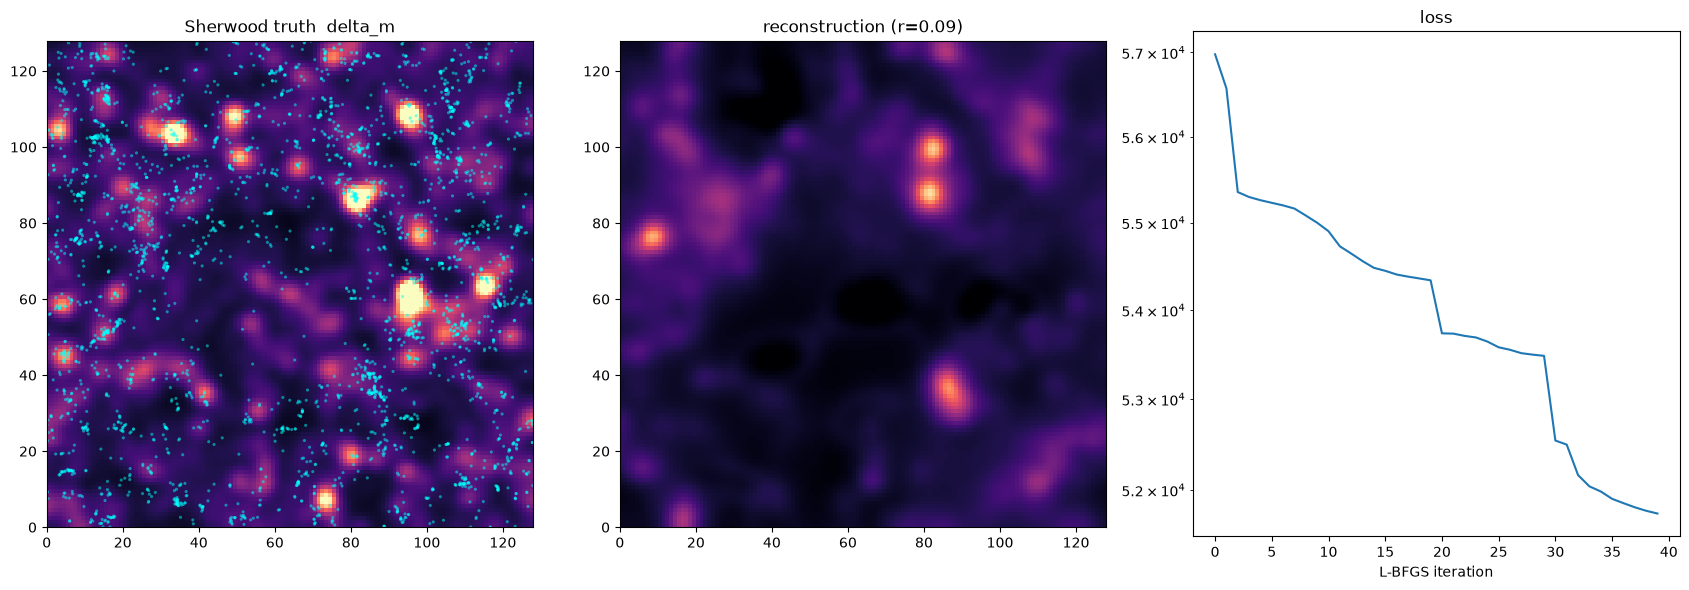

In [140]:
from scipy.ndimage import gaussian_filter

sl = 50
slice_width = 2  # include galaxies within ±0.5 cell of the trans1 slice

pos_cat = catalog.positions
on_slice = np.abs(pos_cat[:, 2] - sl) < slice_width

fig, ax = plt.subplots(1, 3, figsize=(17, 6))
vmin, vmax = np.percentile(truth_delta[:,:,sl], [0, 98])
field_sl = gaussian_filter(truth_delta[:,:,sl], 2)
rec_sl = gaussian_filter(out_sim["delta_m"][:,:,sl], 2)

# galaxies on the same trans1 slice (trans2 vs LOS)
ax[0].scatter(
    pos_cat[on_slice, 0], pos_cat[on_slice, 1],
    s=5, c="cyan", alpha=0.5, edgecolors="none",
)

ax[0].imshow(field_sl.T, vmin=vmin, vmax=vmax, cmap="magma", origin="lower",
             extent=[0, nc_sim, 0, nc_sim])
ax[0].set_title("Sherwood truth  delta_m")
ax[1].imshow(rec_sl.T, vmin=vmin, vmax=vmax,
             cmap="magma", origin="lower", extent=[0, nc_sim, 0, nc_sim])
ax[1].set_title(f"reconstruction (r={c_sim:.2f})")
ax[2].plot(out_sim["loss_history"])
ax[2].set_yscale("log")
ax[2].set_title("loss")
ax[2].set_xlabel("L-BFGS iteration")

fig.tight_layout()

In [45]:
from astropy.cosmology import Planck18
from astropy import units as u

In [54]:
(0.3*u.deg/Planck18.arcsec_per_kpc_comoving(5.7)).to(u.Mpc)*Planck18.h


<Quantity 29.37827978 Mpc>

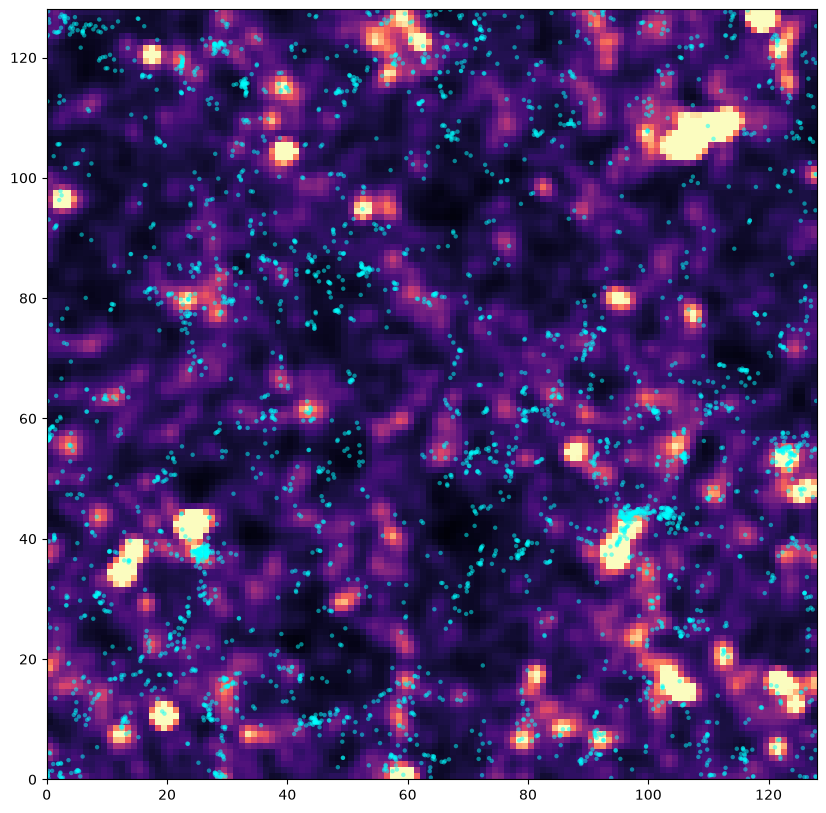

In [133]:
sl = 80
slice_width = 2  # include galaxies within ±0.5 cell of the trans1 slice

# pos_cat = catalog.positions
pos_cat = xyz_grid
on_slice = np.abs(pos_cat[:, 2] - sl) < slice_width

vmin, vmax = np.percentile(truth_delta[:,:,sl], [0, 98])
field_sl = gaussian_filter(truth_delta[:,:,sl], 1)
rec_sl = gaussian_filter(out_sim["delta_m"][:,:,sl], 1)

plt.figure(figsize=(10,10))
plt.scatter(
    pos_cat[on_slice, 0], pos_cat[on_slice, 1],
    s=10, c="cyan", alpha=0.5, edgecolors="none",
)

plt.imshow(field_sl.T, vmin=vmin, vmax=vmax, cmap="magma", origin="lower",
             extent=[0, nc_sim, 0, nc_sim])

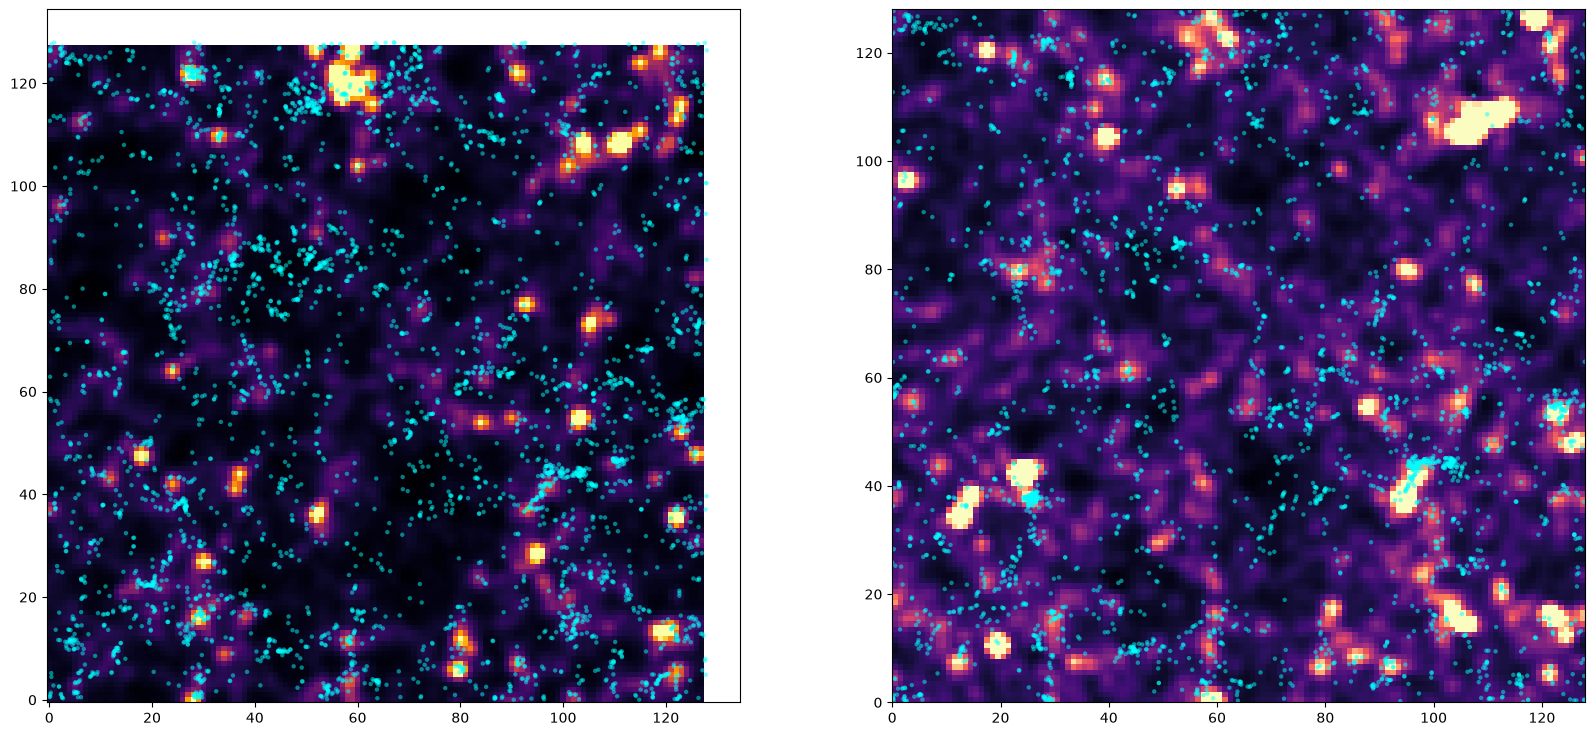

In [135]:
z = np.arange(0,128,1)

lo = 80
hi = 85
idx1 = np.where((lo<z) & (z<hi))[0]
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
plt.imshow(gaussian_filter(np.mean(truth_delta[:,:,idx1],axis=2),1).T,origin='lower',vmax=3,cmap='inferno')
pos_z = xyz_grid[:,2]
idx2 = np.where((lo<pos_z) & (pos_z<hi))[0]
plt.scatter(xyz_grid[idx2][:,0],xyz_grid[idx2][:,1],s=10,ec='none',c='cyan',alpha=0.5)


plt.subplot(1,2,2)

plt.scatter(
    pos_cat[on_slice, 0], pos_cat[on_slice, 1],
    s=10, c="cyan", alpha=0.5, edgecolors="none",
)

plt.imshow(field_sl.T, vmin=vmin, vmax=vmax, cmap="magma", origin="lower",
             extent=[0, nc_sim, 0, nc_sim])